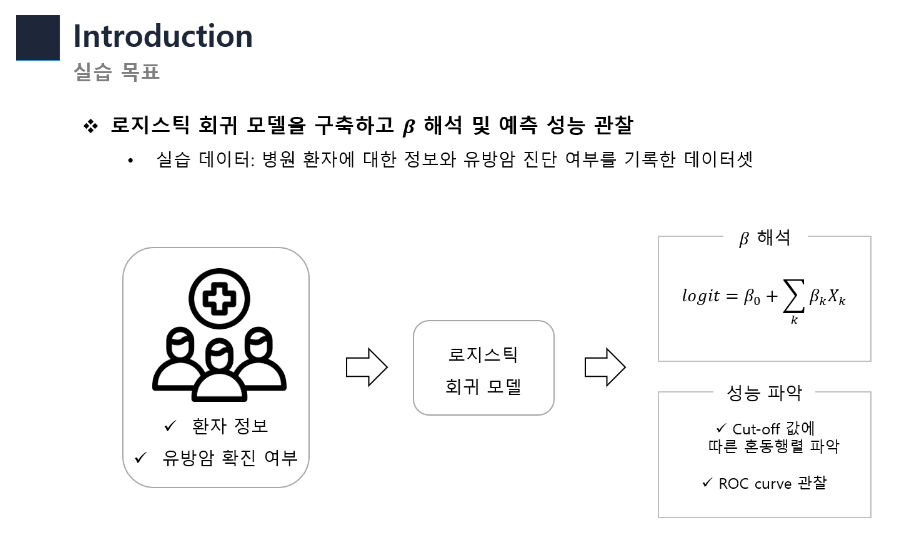

# 로지스틱 회귀 (Logisti Regression)
*   로지스틱 회귀는 이름에 회귀라는 단어가 들어가지만, 가능한 클래스가 2개인 이진 분류를 위한 모델.(멀티 클래스로 확장도 가능)
*   로지스틱 회귀의 예측 함수 정의.


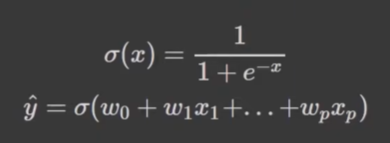

*   σ: 시그모이드 함수.
*   로지스틱 회귀 모델은 선형 회귀 모델에 시그모이드 함수를 적용.
*   로지스틱 회귀의 학습 목표는 다음과 같은 목적 함수를 최소화 하는 파라미터 w를 찾는 것.

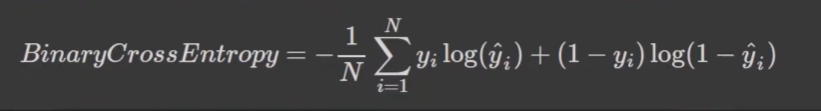

# 로지스틱 회귀 예제

## 1. 모듈 불러오기

In [225]:
### 라이브러리 임포트 및 데이터 생성


import numpy as np           # 수치 계산 및 다차원 배열 처리를 위한 핵심 라이브러리입니다.
import matplotlib.pyplot as plt # 데이터를 그래프나 차트로 시각화하기 위해 사용합니다.

In [226]:
# plt.style.use(['seaborn-whitegrid'])

In [227]:
# sklearn: 머신러닝 모델 구축, 데이터 전처리, 평가 도구를 제공하는 라이브러리
from sklearn.datasets import make_classification # 분류용 가상 데이터를 생성하는 함수입니다.
from sklearn.model_selection import train_test_split, cross_val_score # 데이터를 나누고 교차 검증을 하기 위함입니다.
from sklearn.linear_model import LogisticRegression # 이진 분류의 대표적인 알고리즘인 로지스틱 회귀 모델입니다.

In [228]:
# 한글 폰트 설정
!apt-get -qq install fonts-nanum

In [229]:
# 한글 폰트 설정
import os
from matplotlib import font_manager
import matplotlib.font_manager as fm

fe = fm.FontEntry(
    fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', # ttf 파일이 저장되어 있는 경로
    name='NanumGothic')                        # 원하는 폰트 설정
fm.fontManager.ttflist.insert(0, fe)              # Matplotlib에 폰트 추가

plt.rcParams.update({'font.size': 18, 'font.family': 'NanumGothic'}) # 폰트 설정

In [230]:
### # 데이터 설정 및 생성

##make_classification() 함수는 다음과 같은 매개 변수를 사용합니다.

#n_samples: 생성할 데이터 포인트의 총 수
#n_features: 각 데이터 포인트가 가질 특성 또는 열의 수
#n_informative: 클래스와 관련된 유용한 정보를 가진 특성의 수
#n_redundant: 클래스와 관련이 없는 중복 특성의 수
#n_classes: 생성할 클래스의 수
#random_state: 데이터를 생성하기 위한 무작위 시드


samples = 1000               # 데이터가 많으므로 1000개의 샘플로 진행한다.
X, y = make_classification(
    n_samples=samples,       # 생성할 총 데이터(샘플)의 개수입니다.
    n_features=2,            # 독립 변수의 개수입니다. 여기서는 2차원 평면에 그리기 위해 2개로 설정했습니다.
    n_informative=2,         # 종속 변수(y)와 상관관계가 있는 실질적인 특징의 개수입니다.
    n_redundant=0,           # 다른 특징들로부터 유추 가능한 불필요한 특징(노이즈)을 없애서 모델이 학습하기 쉽게 만듭니다.
    n_clusters_per_class=1,  # 각 클래스(0 또는 1)당 클러스터를 하나씩만 두어 데이터를 뭉치게 만듭니다.
    random_state=123          # 실행할 때마다 결과가 바뀌지 않도록 난수 시드를 고정합니다.
)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


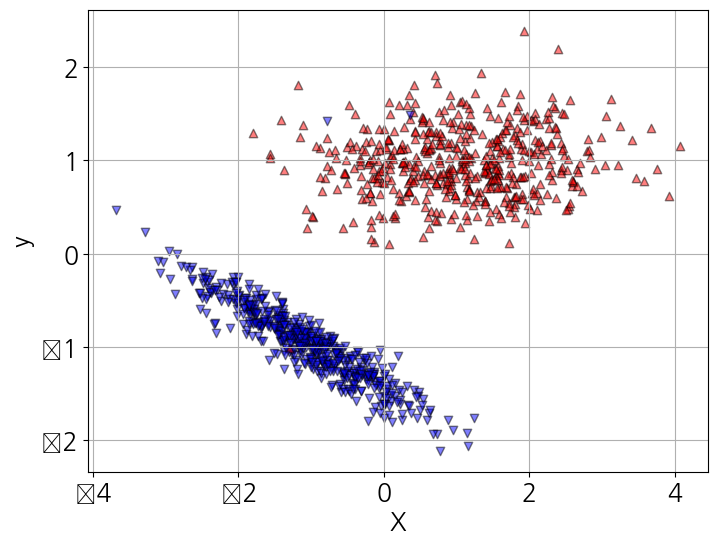

In [231]:
### 데이터 시각화 (데이터 분포 확인) : 모델을 학습시키기 전, 데이터가 어떻게 분포되어 있는지 눈으로 확인하는 단계

# 차트 도화지(fig)와 축(ax) 설정
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.grid()               # 수치 확인이 쉽도록 배경에 격자를 추가합니다.
ax.set_xlabel('X')      # X축의 이름을 설정합니다.
ax.set_ylabel('y')      # y축의 이름을 설정합니다.

# 데이터를 하나씩 순회하며 클래스별로 다른 마커와 색상으로 그립니다.
for i in range(samples):    # sample수만큼 그린다.
  if y[i] == 0:         # 클래스가 0인 경우
    # scatter: 산점도를 그립니다.
    # edgecolors='k': 테두리 검정, alpha: 투명도, marker='^': 삼각형, color='r': 빨간색
    ax.scatter(X[i, 0], X[i, 1], edgecolors='k', alpha=0.5, marker='^', color='r')
  else:                 # 클래스가 1인 경우
    # marker='v': 역삼각형, color='b': 파란색으로 구분하여 시각화합니다.
    ax.scatter(X[i, 0], X[i, 1], edgecolors='k', alpha=0.5, marker='v', color='b')

plt.show() # 생성된 그래프를 화면에 출력합니다.

In [232]:
### 모델 학습 및 평가 : 본격적으로 인공지능 모델을 만들고, 가지고 있는 데이터로 공부(학습)시키는 과정

# train_test_split: 전체 데이터를 학습용(80%)과 검증용(20%)으로 분리합니다.
# 모델이 본 적 없는 데이터(Test)에서도 잘 작동하는지(일반화) 확인하기 위함입니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [233]:
### 모델 학습 및 평가 : 본격적으로 인공지능 모델을 만들고, 가지고 있는 데이터로 공부(학습)시키는 과정

# 로지스틱 회귀 모델 객체를 생성합니다.
model = LogisticRegression()

# fit(): 학습 데이터(X_train)와 정답(y_train)을 넣어 모델을 훈련시킵니다.
# 이 과정에서 데이터 사이의 관계를 나타내는 최적의 선(결정 경계)을 찾습니다.
model.fit(X_train, y_train)

LogisticRegression()

In [234]:
### 모델 학습 및 평가 : 본격적으로 인공지능 모델을 만들고, 가지고 있는 데이터로 공부(학습)시키는 과정

### 학습 데이터와 평가 데이터의 점수 확인
# score(): 모델의 정확도(Accuracy)를 측정합니다. 1.0에 가까울수록 잘 맞추는 것입니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9975
평가 데이터 점수: 0.995


점수가 높다. 로지스틱 회귀는 잘 분류를 하는편. 아직 실무에서 잘쓰이고있다.

In [235]:
### 교차 검증 및 모델 파라미터 확인 : 한 번의 테스트 결과는 우연일 수 있으므로, 여러 번 검증하여 신뢰도를 높입니다.

# cross_val_score: 데이터를 10등분(cv=10)하여 번갈아가며 학습과 검증을 반복합니다.
# 특정 데이터 세트에만 최적화되는 '과적합'을 방지하고 모델의 진짜 실력을 평균값으로 확인합니다.
# cross validation 교차검증을 통해 더 정확한 점수를 확인한다. 10겹으로 확인.
scores = cross_val_score(model, X, y, scoring='accuracy', cv=10)
print("CV 평균 점수: {}".format(scores.mean()))

CV 평균 점수: 0.9970000000000001


In [236]:
### 교차 검증 및 모델 파라미터 확인 : 한 번의 테스트 결과는 우연일 수 있으므로, 여러 번 검증하여 신뢰도를 높입니다.

# 모델이 학습을 통해 도출한 수학적 공식의 계수들을 확인합니다.
# intercept_: y절편 (편향, Bias)
# coef_: 각 특성(X)에 곱해지는 계수 (가중치, Weights)
# 로지스틱 회귀식: y = 1 / (1 + exp(-(w1*x1 + w2*x2 + b))) 형태에서 w와 b를 찾는 것입니다.
print("절편(Bias):", model.intercept_)
print("계수(Weights):", model.coef_)

절편(Bias): [-1.11811692]
계수(Weights): [[-1.87232016 -3.94708193]]


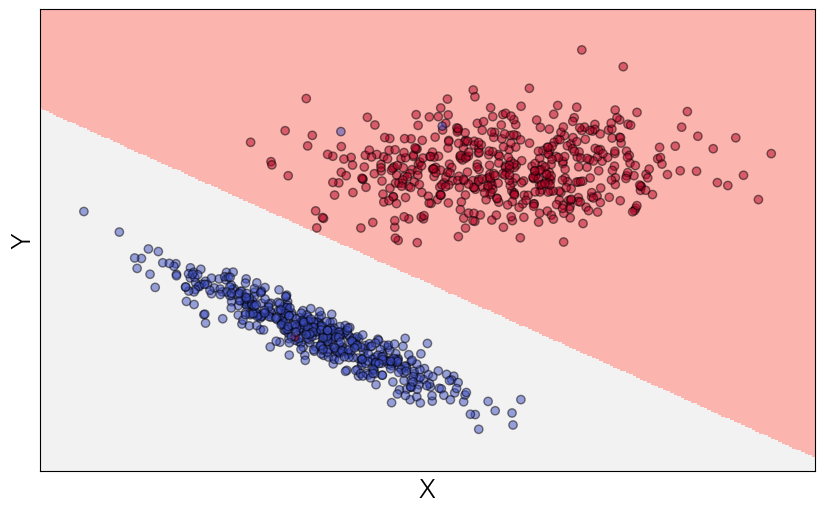

In [237]:
### 로지스틱 회귀의 결과를 시각화


# 1. 그래프의 배경을 채울 영역(범위) 설정
# 데이터의 최소/최대값보다 0.5 정도의 여유를 두어 그래프가 꽉 차지 않게 만듭니다.
x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5

# 2. 격자점(Grid Points) 생성
# np.arange(start, stop, step): 0.02 간격으로 점들을 생성합니다.
# np.meshgrid: 생성된 x축, y축 좌표들을 조합해 평면 위의 모든 '격자점' 좌표를 만듭니다.
# 모든 지점에서의 예측값을 보여주기위한 준비과정
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 3. 모든 격자점에 대한 예측 수행
# xx.ravel(): 2차원 격자 구조를 1차원 배열로 쭉 폅니다.
# np.c_[]: 펴진 x좌표와 y좌표를 쌍(x, y)으로 묶어 모델의 입력 형식으로 만듭니다.
# model.predict(): 학습된 모델이 각 좌표가 어느 클래스(0 또는 1)에 속하는지 예측합니다.
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# 4. 예측 결과를 다시 격자 형태로 변환
# predict 결과는 1차원이므로, 시각화를 위해 원래의 격자 구조(xx.shape)인 2차원으로 다시 바꿉니다.
Z = Z.reshape(xx.shape)

# 5. 그래프 캔버스 설정
plt.figure(1, figsize=(10, 6))

# 6. 결정 경계 채우기 (배경색 설정)
# pcolormesh: 예측된 값(Z)에 따라 배경색을 칠합니다.
# 이를 통해 모델이 어느 영역을 어떤 클래스로 판단하는지 한눈에 볼 수 있습니다.
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Pastel1)

# 7. 실제 데이터 샘플 표시
# X[:, 0], X[:, 1]: 데이터의 실제 특징 값들을 산점도로 그립니다.
# c=np.abs(y - 1): 점의 색상을 실제 정답 레이블(y)에 따라 다르게 표시합니다.
# edgecolors='k': 점의 테두리를 검은색으로 그려 배경과 구분합니다.
# cmap=plt.cm.coolwarm: 클래스에 따라 파란색/빨간색 배정(낮은 값(0에 가까운 값)은 Cool(파란색 계열)로, 높은 값(1에 가까운 값)은 Warm(빨간색 계열)으로 표시)
plt.scatter(X[:, 0], X[:, 1], c=np.abs(y - 1), edgecolors='k', alpha=0.5, cmap=plt.cm.coolwarm)

# 8. 축 라벨 설정
plt.xlabel('X')
plt.ylabel('Y')

# 9. 그래프 범위 및 축 스타일 설정
plt.xlim(xx.min(), xx.max()) # x축 범위를 생성한 격자 범위로 고정
plt.ylim(yy.min(), yy.max()) # y축 범위를 생성한 격자 범위로 고정
plt.xticks(())               # 축의 눈금을 없애 깔끔하게 시각화 (선택 사항)
plt.yticks(())

# 10. 그래프 화면 출력
plt.show()

보여지는 경계가 로지스틱 회귀의 결과이다.

# 붓꽃 데이터

In [238]:
### 데이터 로드 및 탐색

# 사이킷런에서 기본 제공하는 붓꽃 데이터셋 임포트
from sklearn.datasets import load_iris # 붓꽃 데이터는 머신러닝에서 매우 유명한 데이터 셋이다.(머신러닝의 '헬로 월드'라 불리는 붓꽃(Iris) 데이터셋)

iris = load_iris() # 데이터를 불러와 iris 변수에 저장 (딕셔너리와 유사한 Bunch 객체)

print(iris.keys())  # 데이터셋의 구성 요소(data, target, feature_names 등) 확인
print(iris.DESCR)   # 데이터셋의 상세 설명(샘플 수, 특성 정보 등) 출력

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= =====

붓꽃의 꽃잎, 꽃받침의 너비와 길이를 통해 종을 예측하여 분류하는 데이터 셋이다.

In [239]:
### 판다스(Pandas) 데이터프레임 변환 : 데이터를 표 형태로 변환하여 분석하기 쉽게 만듭니다.

import pandas as pd

# iris.data(수치)를 데이터프레임으로 만들고 컬럼명을 설정합니다.
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 정수형 타겟(0, 1, 2)을 카테고리 타입 시리즈로 변환합니다.
species = pd.Series(iris.target, dtype='category')

# 숫자로 된 카테고리를 실제 꽃 이름(Setosa 등)으로 변경하여 가독성을 높입니다.
species = species.cat.rename_categories(iris.target_names)

# 생성한 종(species) 정보를 기존 데이터프레임의 새 컬럼으로 합칩니다.
iris_df['species'] = species

In [240]:
### 통계적 요약

iris_df.describe() # 평균, 표준편차, 사분위수 등 기술 통계량을 한눈에 확인합니다.

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


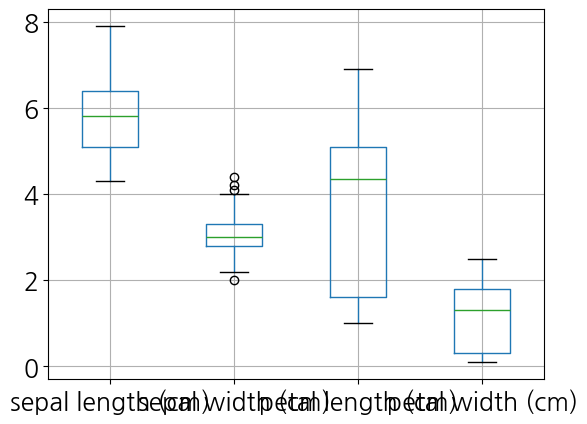

In [241]:
### 시각화 : 데이터의 분포와 이상치를 시각적으로 파악합니다.

iris_df.boxplot();  # 각 특성별 수치 분포와 이상치(Outlier)를 박스 플롯으로 그립니다.

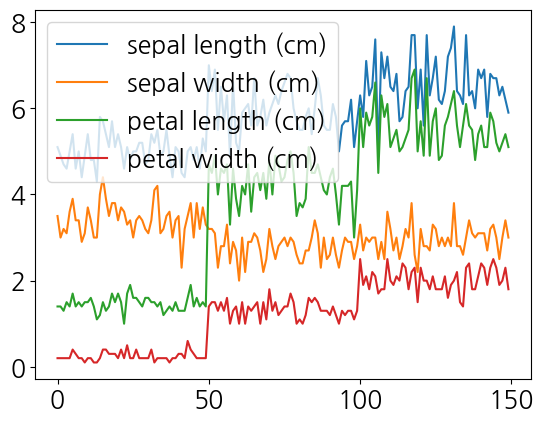

In [242]:
### 시각화 : 데이터의 분포와 이상치를 시각적으로 파악합니다.

iris_df.plot();     # 전체 데이터의 변화 추이를 선 그래프로 확인합니다.

대략 0 ~ 50사이의 그룹이 있고 50 ~ 100사이의 그룹이 있고 100 ~ 150사이에 그룹이 있음을 볼 수 있다.

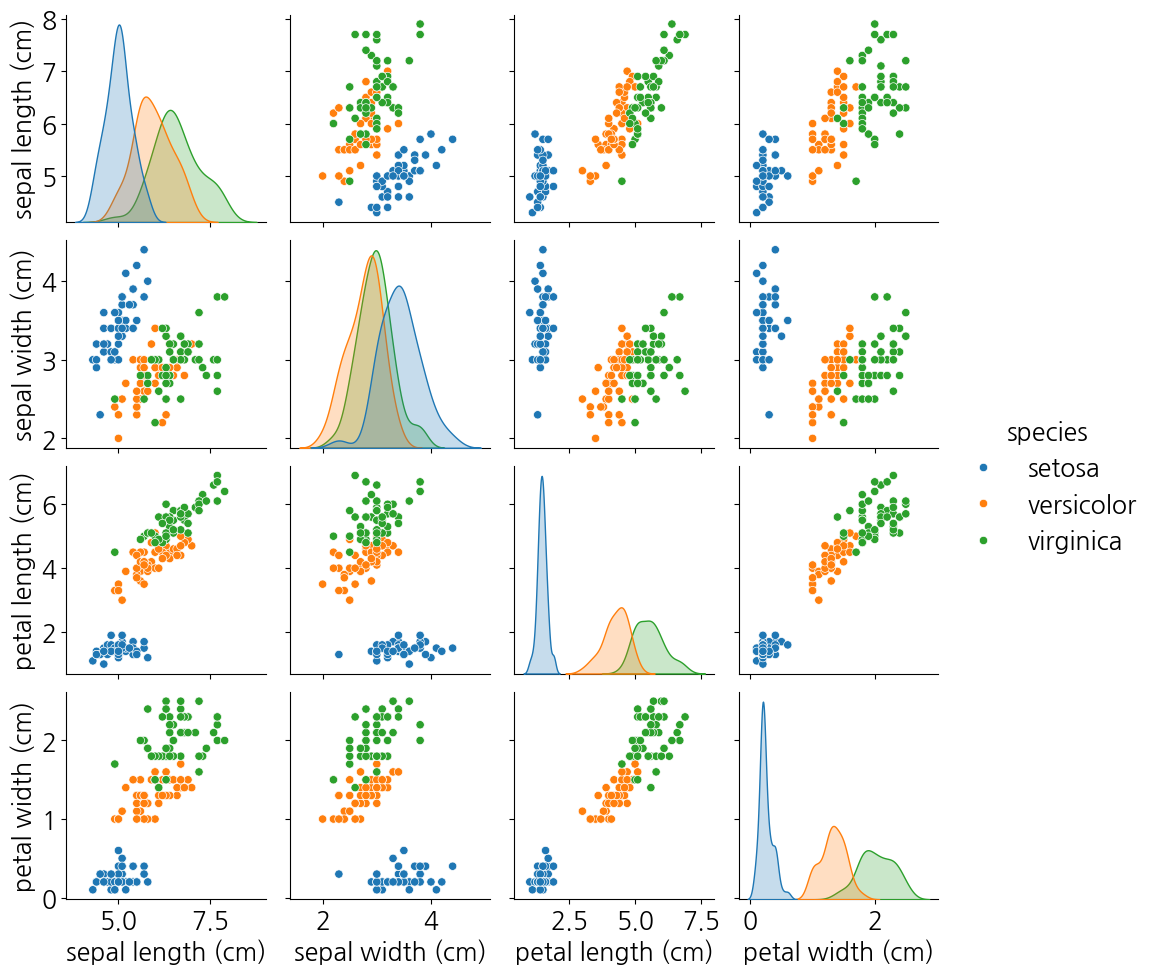

In [243]:
### 시각화 : 데이터의 분포와 이상치를 시각적으로 파악합니다.

import seaborn as sns
# 모든 특성 조합에 대한 산점도를 그리고, 종별로 색상을 구분(hue)하여 관계를 파악합니다.
sns.pairplot(iris_df, hue='species');

파란색은 예측력 높게 분류 될 수 있을 것같다.

# 붓꽃 데이터에 대한 로지스틱 회귀

In [244]:
### 데이터 분할 : 학습용 데이터와 검증용 데이터를 나눕니다.

import sklearn.model_selection as model_selection

# 특성 중 꽃잎 길이와 너비(2, 3번째 컬럼)만 선택하고 데이터를 나눕니다.
# test_size=0.2: 20%는 테스트용, stratify: 정답 클래스 비율을 유지하며 분할하여 편향 방지(계층적 구조를 띌때 도움됨)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris.data[:, [2, 3]], iris.target, test_size=0.2, random_state=1, stratify=iris.target)

In [245]:
### 모델 학습 : 인공지능 모델을 훈련시킵니다.

from sklearn.linear_model import LogisticRegression

# 로지스틱 회귀 모델 생성
# C=100.0: 규제 강도(낮을수록 강력) <= 하이퍼파라미터, solver: 최적화 알고리즘 설정 lbfgs <= 기본값, multi_class='auto'도 기본값
model = LogisticRegression(solver='lbfgs', multi_class='auto', C=100.0, random_state=1)

# 학습 데이터로 모델을 훈련(Fitting)시킵니다.
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100.0, multi_class='auto', random_state=1)

In [246]:
# 모델의 정확도 점수를 출력하여 성능을 확인합니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9666666666666667
평가 데이터 점수: 0.9666666666666667


In [247]:
### 결정 경계(Decision Boundary) 시각화 준비 : 모델이 어떻게 데이터를 구분하고 있는지 배경색으로 표현하기 위한 작업

import numpy as np
# 시각화를 위해 흩어져 있던 학습/테스트 데이터를 다시 하나로 합칩니다.
X = np.vstack((X_train, X_test))
y = np.hstack((y_train, y_test))

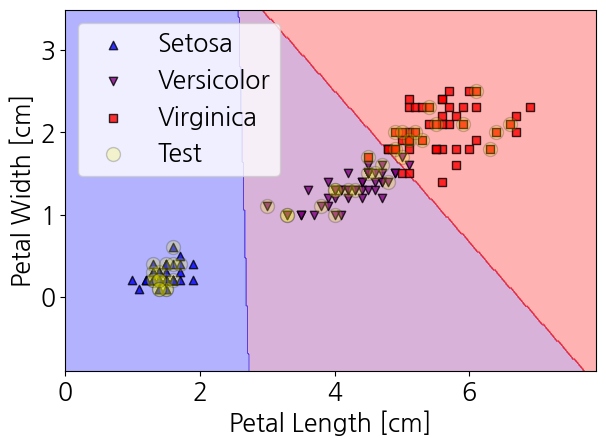

In [248]:
### 결정 경계(Decision Boundary) 시각화 준비 : 모델이 어떻게 데이터를 구분하고 있는지 배경색으로 표현하기 위한 작업
### 최종 그래프 출력 : 모델의 판단 영역과 실제 데이터 포인트를 겹쳐서 그립니다.

from matplotlib.colors import ListedColormap

# 그래프의 최소/최대 범위를 설정합니다.

# 그래프의 경계선(캔버스 크기) 정하기 : 모델이 예측할 공간의 '좌측 끝, 우측 끝, 위 끝, 아래 끝'을 정하는 단계
# X[:, 0]은 첫 번째 특성(꽃잎 길이), X[:, 1]은 두 번째 특성(꽃잎 너비)입니다.
# .min() - 1과 .max() + 1을 하는 이유는 데이터들이 그래프 테두리에 딱 붙지 않고
# 여유 있게(마진 1) 안쪽으로 들어오게 하여 보기 좋게 만들기 위함입니다.

x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1

# 가상의 바둑판(Meshgrid) 만들기 : 색칠을 하려면 아주 촘촘한 점들이 필요합니다. 마치 모니터의 픽셀처럼

# 격자점(Meshgrid)을 생성하여 전체 영역에 대한 예측값을 구합니다.
# np.arange(시작, 끝, 간격): 0.02라는 아주 촘촘한 간격으로 좌표 숫자들을 생성합니다.
# np.meshgrid: 이 숫자들을 조합해 가로줄(xx1)과 세로줄(xx2)이 교차하는 '바둑판 좌표'를 만듭니다.
# 결과적으로 xx1과 xx2는 우리가 색칠할 전체 평면의 모든 좌표 정보를 갖게 됩니다.
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.02), np.arange(x2_min, x2_max, 0.02))

# 이 촘촘한 바둑판의 점 하나하나를 모델에게 물어보기.
# xx1.ravel(): 2차원 바둑판을 한 줄로 길게 펼칩니다.
# np.array(...).T: 펼쳐진 x좌표와 y좌표를 쌍으로 묶어 모델이 읽을 수 있는 데이터 형식으로 만듭니다.
# model.predict(...): 모델이 수만 개의 격자점 하나하나에 대해 "여기는 0번 클래스 영역이네!",
# "여기는 1번이네!"라고 답을 내놓고, 그 결과를 Z에 저장합니다.
Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T) # 격자의 모든 점에 대해 예측

# 예측 결과를 다시 바둑판 모양으로 조립하기 : 모델의 답변(Z)은 현재 일렬로 나열된 상태입니다.
# 이를 다시 그래프에 그릴 수 있도록 원래의 바둑판 모양으로 되돌립니다.
# Z.reshape(xx1.shape): 일렬로 늘어선 예측값들을 다시 xx1(바둑판)과 똑같은 행렬 형태로 바꿉니다.
# 이렇게 해야 나중에 plt.contourf 함수가 "아, 이 위치엔 이 색을 칠하면 되는구나"라고 이해할 수 있습니다.
Z = Z.reshape(xx1.shape) # 예측 결과를 격자 모양으로 재배열

# 시각화 요소 설정 (색상 및 마커) : 그래프에서 각 꽃의 종류를 구분하기 위한 디자인 요소를 정의

# 그래프 범례에 표시할 실제 꽃 이름을 튜플로 정의합니다.
species = ('Setosa', 'Versicolor', 'Virginica')
# 각 클래스별로 다른 모양의 점(마커)을 사용합니다. (^:삼각형, v:역삼각형, s:사각형)
markers = ('^', 'v', 's')
# 각 클래스별 배경 및 점의 색상을 지정합니다.
colors = ('blue', 'purple', 'red')
# ListedColormap: 설정한 색상 리스트를 matplotlib에서 사용할 수 있는 컬러맵 형태로 변환합니다.
# len(np.unique(y))를 통해 실제 데이터에 존재하는 클래스 개수만큼 색상을 슬라이싱합니다.
cmap = ListedColormap(colors[:len(np.unique(y))])

# 결정 경계(배경색) 그리기 : 모델이 "이 영역은 무슨 꽃이다"라고 판단한 구역을 색칠하는 과정

# plt.contourf: '등고선 채우기' 함수입니다. 여기서는 모델의 예측값(Z)에 따라 배경색을 채웁니다.
# xx1, xx2 격자 좌표 위에서 모델이 예측한 Z값(클래스)에 따라 cmap 색상을 입힙니다.
# alpha=0.3: 배경색이 너무 진하면 데이터 점이 안 보이므로 투명도를 낮게 설정합니다.
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)

# 그래프의 X축과 Y축 표시 범위를 계산된 격자의 최소/최대값으로 고정합니다.
plt.xlim(xx1.min(), xx1.max())
plt.ylim(xx2.min(), xx2.max())

# 실제 데이터 포인트(산점도) 그리기
# np.unique(y): 중복을 제거한 타겟값 [0, 1, 2]를 가져와 반복문을 돌립니다.
for idx, cl in enumerate(np.unique(y)):
    # plt.scatter: 산점도를 그립니다.
    # X[y == cl, 0]: 정답(y)이 현재 클래스(cl)인 데이터의 첫 번째 특성(꽃잎 길이)
    # X[y == cl, 1]: 정답(y)이 현재 클래스(cl)인 데이터의 두 번째 특성(꽃잎 너비)
    plt.scatter(x=X[y == cl, 0], y = X[y == cl, 1],
                alpha=0.8,              # 점의 투명도
                c=colors[idx],          # 클래스별 지정 색상
                marker=markers[idx],    # 클래스별 지정 마커
                label=species[cl],      # 범례에 표시될 이름
                edgecolor='k')          # 점의 테두리를 검정색('k')으로 그려 구분감 제공

# 테스트 데이터 강조 및 마무리 : 모델이 학습할 때 보지 못했던 '테스트 데이터'가 어디에 위치하는지 별도로 강조합니다.
# 전체 데이터 중 일부(여기서는 인덱스 105~149번)를 테스트 데이터로 간주하여 추출합니다.
X_comb_test, y_comb_test = X[range(105, 150), :], y[range(105, 150)]

# 테스트 데이터 포인트를 노란색('yellow')의 큰 원('o')으로 겹쳐 그려서 강조합니다.
# s=100: 점의 크기를 크게 하여 눈에 띄게 합니다.
# alpha=0.2: 뒤에 있는 원래 데이터 점도 보이도록 아주 투명하게 설정합니다.
plt.scatter(X_comb_test[:, 0], X_comb_test[:, 1],
            c = 'yellow', edgecolor='k', alpha=0.2,
            linewidth=1, marker='o',
            s=100, label='Test')

# 축 이름과 범례를 설정합니다.
plt.xlabel('Petal Length [cm]')  # X축 라벨
plt.ylabel('Petal Width [cm]')   # Y축 라벨
plt.legend(loc='upper left')     # 범례를 왼쪽 상단에 표시
plt.tight_layout();              # 그래프 요소들(축, 제목 등)이 겹치지 않게 레이아웃 자동 조정

In [249]:
### 그리드 서치(Grid Search) 설정 : 모델의 여러 설정값(파라미터) 후보군을 정하고, 어떤 방식으로 찾을지 설계하는 단계


import multiprocessing # 내 컴퓨터의 CPU 코어 개수를 알아내기 위해 사용합니다.
from sklearn.model_selection import GridSearchCV # 최적의 설정을 자동으로 찾아주는 '그리드 서치' 도구입니다.

# param_grid: 테스트해볼 후보지입니다.
# 'penalty': 규제 방식(l1은 불필요한 특징 제거, l2는 특징의 힘을 약화)
# 'C': 규제의 강도 (숫자가 커질수록 규제가 약해집니다.)
# 총 2(penalty) x 5(C) = 10가지의 조합을 시도하게 됩니다.
param_grid = [{'penalty': ['l1', 'l2'],
               'C': [2.0, 2.2, 2.4, 2.6, 2.8]}]

# GridSearchCV 객체 생성
gs = GridSearchCV(
    estimator=LogisticRegression(), # 테스트할 기본 모델을 로지스틱 회귀로 설정합니다.
    param_grid=param_grid,          # 위에서 정의한 10가지 조합을 사용합니다.
    scoring='accuracy',             # 평가 기준은 '정확도'로 설정합니다.
    cv=10,                          # 각 조합당 10겹 교차 검증(10-Fold CV)을 수행합니다. (총 100번 학습)
    n_jobs=multiprocessing.cpu_count() # CPU의 모든 코어를 동원해 병렬로 빠르게 계산합니다.
)

gs

GridSearchCV(cv=10, estimator=LogisticRegression(), n_jobs=2,
             param_grid=[{'C': [2.0, 2.2, 2.4, 2.6, 2.8],
                          'penalty': ['l1', 'l2']}],
             scoring='accuracy')

In [250]:
### 학습 실행 (최적의 조합 찾기) : 설계도를 바탕으로 실제로 모든 조합을 대입해 학습을 진행합니다.


# fit(): 10가지 파라미터 조합에 대해 각각 10번씩 학습과 검증을 반복합니다.
# 가장 평균 점수가 높게 나오는 '황금 조합'을 찾아 내부적으로 저장합니다.
result = gs.fit(iris.data, iris.target)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

In [251]:
### 결과 확인 및 분석 : 컴퓨터가 찾아낸 최적의 설정값과 그동안의 시도 내역을 확인


# gs.best_estimator_: 가장 성적이 좋았던 설정이 적용된 '완성형 모델' 객체를 보여줍니다.
print(gs.best_estimator_)

# gs.best_score_: 10겹 교차 검증을 통해 얻은 가장 높은 평균 정확도 점수입니다.
print("최적 점수: {}".format(gs.best_score_))

# gs.best_params_: 10가지 조합 중 1등을 차지한 구체적인 설정값입니다.
print("최적 파라미터: {}".format(gs.best_params_))

# result.cv_results_: 모든 조합에 대한 상세한 테스트 결과(시간, 점수 등)가 들어있습니다.
# 이를 pd.DataFrame으로 만들면 표 형태로 깔끔하게 분석할 수 있습니다.
pd.DataFrame(result.cv_results_)

LogisticRegression(C=2.4)
최적 점수: 0.9800000000000001
최적 파라미터: {'C': 2.4, 'penalty': 'l2'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000604,0.000109,0.000000,0.000000,2.0,l1,"{'C': 2.0, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
1,0.034087,0.006351,0.002411,0.001618,2.0,l2,"{'C': 2.0, 'penalty': 'l2'}",1.0,0.933333,1.0,1.0,0.933333,0.933333,0.933333,1.0,1.0,1.0,0.973333,0.032660,4
2,0.000731,0.000383,0.000000,0.000000,2.2,l1,"{'C': 2.2, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,0.037686,0.011370,0.002588,0.001212,2.2,l2,"{'C': 2.2, 'penalty': 'l2'}",1.0,0.933333,1.0,1.0,0.933333,0.933333,0.933333,1.0,1.0,1.0,0.973333,0.032660,4
4,0.001577,0.001477,0.000000,0.000000,2.4,l1,"{'C': 2.4, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
5,0.032660,0.006386,0.002003,0.000248,2.4,l2,"{'C': 2.4, 'penalty': 'l2'}",1.0,0.933333,1.0,1.0,0.933333,1.000000,0.933333,1.0,1.0,1.0,0.980000,0.030551,1
6,0.001003,0.000770,0.000000,0.000000,2.6,l1,"{'C': 2.6, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
7,0.035052,0.008201,0.003026,0.002379,2.6,l2,"{'C': 2.6, 'penalty': 'l2'}",1.0,0.933333,1.0,1.0,0.933333,1.000000,0.933333,1.0,1.0,1.0,0.980000,0.030551,1
8,0.000817,0.000731,0.000000,0.000000,2.8,l1,"{'C': 2.8, 'penalty': 'l1'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
9,0.031902,0.005469,0.002222,0.000793,2.8,l2,"{'C': 2.8, 'penalty': 'l2'}",1.0,0.933333,1.0,1.0,0.933333,1.000000,0.933333,1.0,1.0,1.0,0.980000,0.030551,1


# 유방암 데이터

## 1. 모듈 불러오기

In [252]:
### 유방암 데이터셋 로드
#
#from sklearn.datasets import load_breast_cancer # 유방암 진단 데이터셋 임포트

In [253]:
### 필수 라이브러리 및 데이터 불러오기
### 유방암 데이터셋 로드

# 실습용 데이터 패키지
from sklearn.datasets import load_breast_cancer # 유방암 진단 데이터셋 임포트

# 데이터 전처리 패키지
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 기계학습 모델 구축 및 평가 패키지
from sklearn.linear_model import LogisticRegression  # 분류 알고리즘(로지스틱 회귀)
from sklearn.model_selection import train_test_split # 데이터 분할 도구
from sklearn.metrics import roc_curve, accuracy_score, confusion_matrix, recall_score, precision_score

# 데이터 시각화 패키지
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
#plt.rc('font', family='Malgun Gothic')

In [254]:
## 데이터셋 로드 및 설명
#breast_cancer = load_breast_cancer()
#print(breast_cancer.DESCR)

## 2. 데이터 불러오기

In [255]:
### 유방암 데이터셋 로드

# 데이터셋 로드 및 설명
breast_cancer = load_breast_cancer() # 데이터를 불러와 변수에 저장
print(breast_cancer.keys())          # 데이터의 구성 요소(데이터, 타겟, 변수명 등) 확인
print(breast_cancer.DESCR)           # 데이터셋에 대한 상세 설명(샘플 수 569개, 변수 30개 등) 출력

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 f

위의 결과를 보면 데이터는 총 569개, 독립변수는 30개, 그리고 피쳐들에 대한 정보, 기초 통게량, 클래스 정보가 보여진다.

In [256]:
# X 변수 및 Y 변수 확인 # 변수 정보
print(breast_cancer.feature_names)
print(breast_cancer.target_names) ## class {"0":'malignant',"1":"benign"} # 유방암 양성/음성 => 0이 유방암이다/ 1이 유방암이 아니다.

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


In [257]:
# 타깃 정보
breast_cancer.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [258]:
# 0과 1의 의미 서로 바꾸기  => 1이 유방암이다/ 0이 유방암이 아니다.
# P(Y=1) : 유방암일 확률 , P(Y=0) : 유방암이 아닐 확률 && class {"1":'malignant',"0":"benign"}
breast_cancer.target = np.where(breast_cancer.target==0,1,0) ## np.where() 조건문 # 0이면 1로 바꿔주세요 그렇지않으면 1로 바꿔주세요.

In [259]:
### 데이터프레임 변환 및 확인

import pandas as pd

# 30개의 특성(feature) 데이터를 데이터프레임으로 변환합니다.
cancer_df = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)

# 'Target' 컬럼을 추가합니다. (0: 악성 종양-Malignant, 1: 양성 종양-Benign)
cancer_df['Target'] = breast_cancer.target

# 데이터의 상위 5행만 출력하여 전체적인 구조를 눈으로 확인합니다.
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [260]:
### 통계적 요약 : 데이터의 전반적인 수치 분포를 파악

# 각 변수별 개수, 평균, 표준편차, 최소값, 사분위수, 최대값을 요약해서 보여줍니다.
# 이를 통해 변수마다 값의 범위(Scale)가 얼마나 차이 나는지 알 수 있습니다.
cancer_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


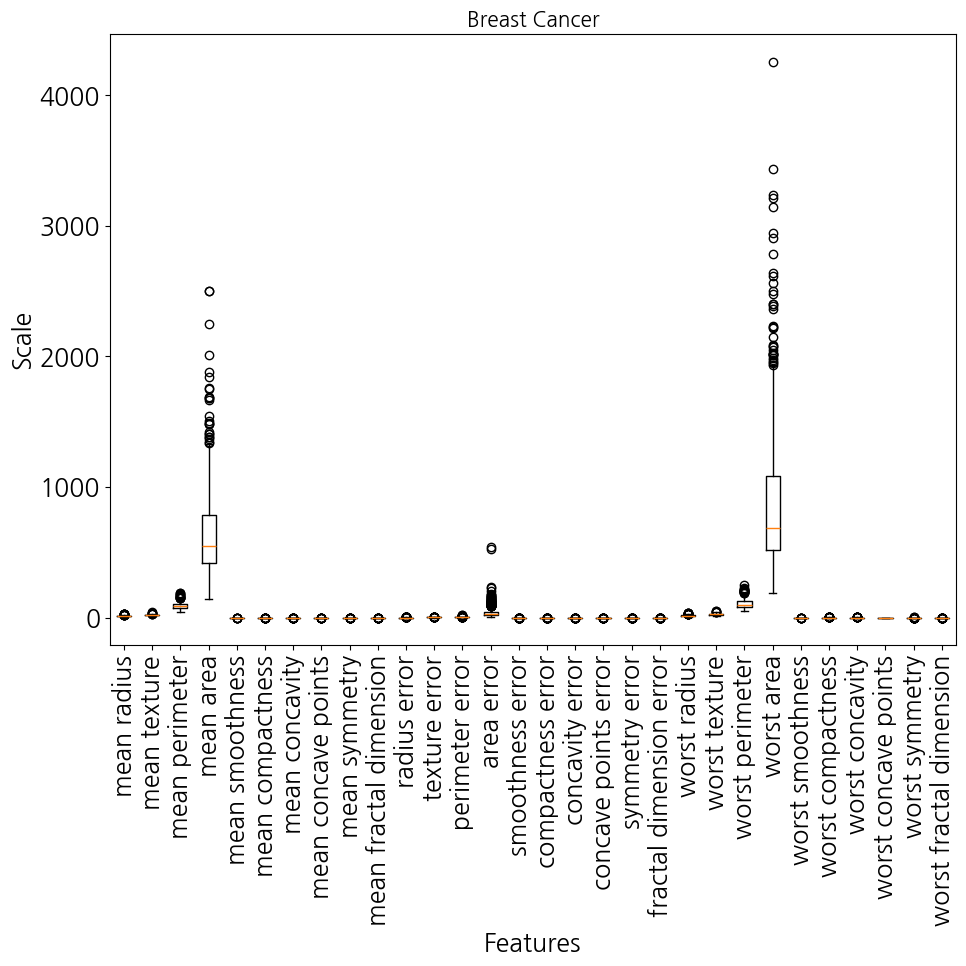

In [261]:
### 박스 플롯(Boxplot) 시각화 : 30개나 되는 변수들의 범위를 한꺼번에 비교하여 데이터 전처리의 필요성을 확인하는 중요한 단계

fig = plt.figure(figsize=[10, 10]) # 그래프의 크기를 가로 10, 세로 10으로 설정
plt.title('Breast Cancer', fontsize=15) # 그래프 제목 설정

# 30개의 모든 특성 데이터를 박스 플롯으로 그립니다.
# 데이터의 중앙값, 이상치, 분포 범위를 한눈에 볼 수 있습니다.
plt.boxplot(breast_cancer.data)

# X축 눈금 설정
# np.arange(30)+1: 1부터 30까지 눈금을 만듭니다.
# labels=cancer.feature_names: 각 눈금에 변수 이름을 붙입니다.
# rotation=90: 변수 이름이 길어 서로 겹치므로 90도 회전시켜 세로로 표시합니다.
plt.xticks(np.arange(30)+1, breast_cancer.feature_names, rotation=90)

plt.xlabel('Features') # X축 이름: 특성들
plt.ylabel('Scale')    # Y축 이름: 수치 범위
plt.tight_layout()     # 여백을 조절하여 글자가 잘리지 않게 조정

두가지 피쳐가 두드러져보인다.

# 유방암 데이터에 대한 로지스틱 회귀

In [262]:
### 데이터 분할

# return_X_y=True: 데이터셋 객체 전체를 가져오는 대신,
# 독립 변수(X, 특성 30개)와 종속 변수(y, 정답)만 깔끔하게 튜플 형태로 반환받습니다.
#X, y = load_breast_cancer(return_X_y=True)

# 전체 데이터를 학습용과 테스트용으로 나눕니다.
# 비율을 지정하지 않으면 기본적으로 75%(학습) : 25%(테스트)로 나누어집니다.
#X_train, X_test, y_train, y_test = train_test_split(X, y)

In [263]:
### 데이터 분할

# return_X_y=True: 데이터셋 객체 전체를 가져오는 대신,
# 독립 변수(X, 특성 30개)와 종속 변수(y, 정답)만 깔끔하게 튜플 형태로 반환받습니다.
#X, y = load_breast_cancer(return_X_y=True)

# Train set/ Test set 나누기
# 전체 데이터를 학습용과 테스트용으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(breast_cancer.data,
                                                   breast_cancer.target,
                                                   test_size=0.3,       # 비율을 지정하지 않으면 기본적으로 70%(학습) : 30%(테스트)로 나누어집니다.
                                                   random_state=2021)   # random_state는 Train set/ Test set 나누는데 랜덤하게 나누어지는데 그 랜덤성을 고정시키겠다는뜻.(시드값고정)
# 데이터 컬럼 단위 정규화 하기 # 데이터의 단위를 정규화하기
normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)

## 4. 로지스틱 회귀 모델 구축하기

### 4.1 모델 학습하기

In [264]:
### 모델 생성 및 학습

# model 불러오기
# LogisticRegression(max_iter=3000)
# max_iter: 모델이 최적의 정답(가중치)을 찾기 위해 최대 몇 번까지 반복 계산할 것인지 정합니다.
# 유방암 데이터는 특성이 30개나 되어 계산이 복잡하기 때문에,
# 기본값(100)으로는 정답에 도달하기 전 계산이 끝날 수 있어 3000으로 충분히 높여준 것입니다.
model = LogisticRegression(max_iter=3000)

# model 학습시키기
# fit(): 준비된 학습 데이터와 정답을 보고 모델이 규칙(수식)을 찾아냅니다.
model.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

### 4.2 $\beta$ 확인하기

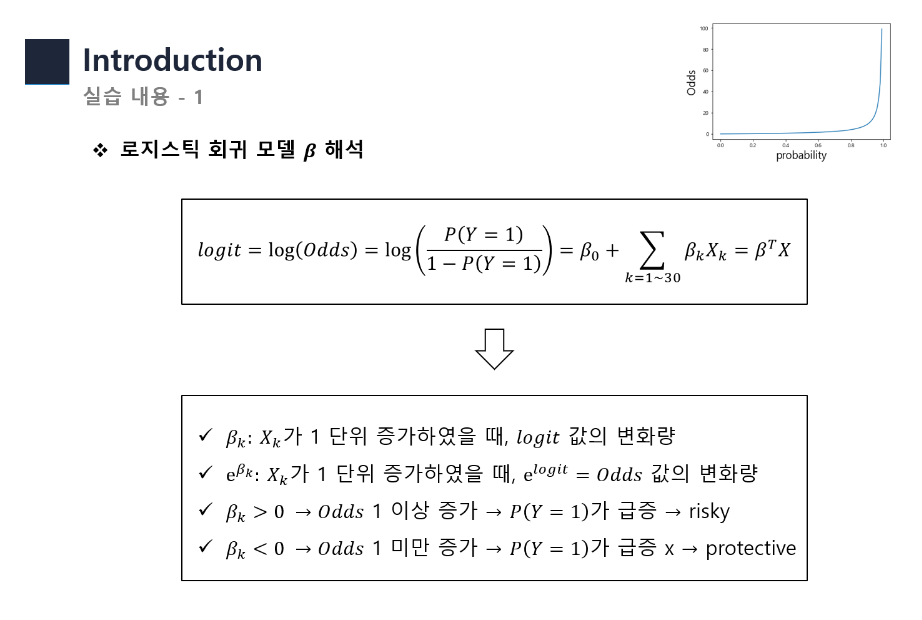

학습된 데이터로 베타값 확인하기.

In [265]:
model.intercept_

array([-0.4231199])

In [266]:
model.coef_

array([[ 0.54551397,  0.92672459,  0.55305135,  0.55999742,  0.13825232,
        -0.48423658,  0.92052875,  0.7321745 ,  0.23929556, -0.64880997,
         1.08285605, -0.56606568,  0.80878188,  0.86095121,  0.2935992 ,
        -0.45929553, -0.13189665,  0.27125868, -0.4195727 , -0.41804417,
         0.78167308,  1.16332525,  0.75204315,  0.76870191,  0.99845584,
        -0.09413619,  0.67536124,  0.98610116,  1.09344359,  0.18328444]])

In [267]:
# 데이터 컬럼에 따른 beta, exp(beta) 체크
column_name = ["const"] + breast_cancer.feature_names.tolist()  # 컬럼에 상수값 추가 => 선형회귀 모델에서 상수값 없을경우 0,0을 지나므로

# model.intercept_는 베타0값, model.coef_는 베타1부터 각 베타값(각 독립변수에 대한 베타값).
# model.intercept_,model.coef_을 병합하여 소수점 둘재자리까지 반올림.
beta = np.concatenate([model.intercept_,model.coef_.reshape(-1)]).round(2) # round(2) 소수점 둘째짜리까지 반올림

odds = np.exp(beta).round(2) # round(2) 소수점 둘째짜리까지 반올림 # odds값 계산

# 베타값이 0보다 크면 'risky'(위험), 작으면 'protective'(안전) => interpret(해석)이라는 값에 할당.
interpret = np.where(beta>0,'risky','protective') # np.where() 조건문

# beta 해석 정리 # 각 변수별로 어떤 영향을 미치는지 => 위험 또는 안전에 영향을 주는지
beta_analysis = pd.DataFrame(np.c_[beta,odds,interpret],index=column_name,columns=['beta','exp(beta)','interpret'])
beta_analysis

,beta,exp(beta),interpret
const,-0.42,0.66,protective
mean radius,0.55,1.73,risky
mean texture,0.93,2.53,risky
mean perimeter,0.55,1.73,risky
mean area,0.56,1.75,risky
mean smoothness,0.14,1.15,risky
mean compactness,-0.48,0.62,protective
mean concavity,0.92,2.51,risky
mean concave points,0.73,2.08,risky
mean symmetry,0.24,1.27,risky


### 4.3 Test data 예측하기

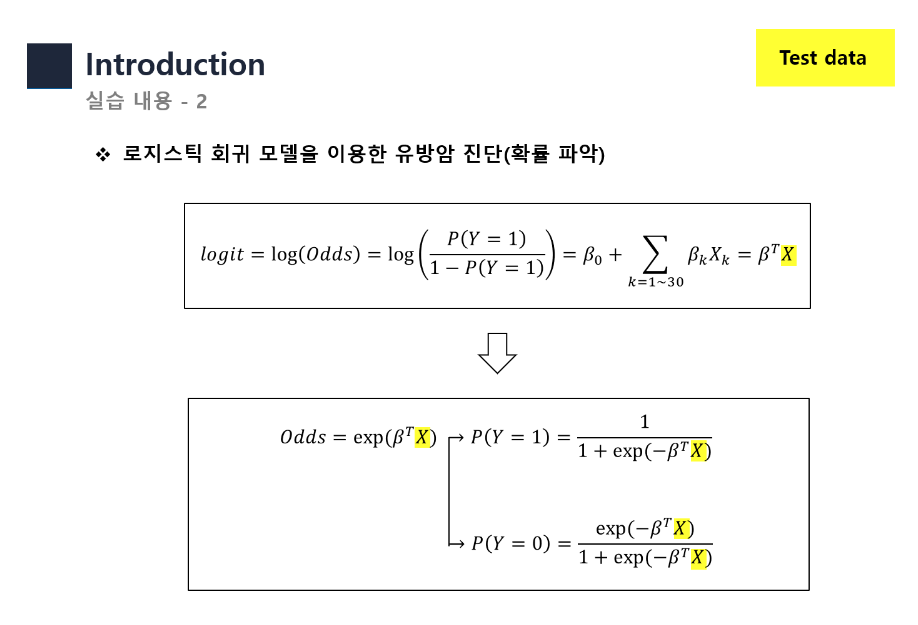

학습데이터로 학습된 베타값의 회귀식에 테스트 데이터를 입력하여 테스트 데이터에 대한 예측 확률값은 어떻게 되는지 확인하기.

In [268]:
# X_test에 대한 P(Y=0) 예측 확률값과 P(Y=1) 예측 확률값 - 패키지 이용 계산
# 첫번째 컬럼이 P(Y=0)일 확률, 두번째 컬럼이 P(Y=1)일 확률.
model.predict_proba(X_test)

array([[9.99580975e-01, 4.19024676e-04],
       [9.99985746e-01, 1.42539725e-05],
       [9.92734002e-01, 7.26599785e-03],
       [2.67563749e-13, 1.00000000e+00],
       [9.99986508e-01, 1.34923124e-05],
       [9.84052285e-02, 9.01594772e-01],
       [9.96336158e-07, 9.99999004e-01],
       [9.99932607e-01, 6.73934938e-05],
       [8.09110980e-05, 9.99919089e-01],
       [9.99995184e-01, 4.81585676e-06],
       [9.99999650e-01, 3.50464639e-07],
       [7.05611810e-06, 9.99992944e-01],
       [9.89398639e-01, 1.06013611e-02],
       [5.07811511e-04, 9.99492188e-01],
       [9.99283452e-01, 7.16547844e-04],
       [9.99223320e-01, 7.76680255e-04],
       [9.37604348e-01, 6.23956516e-02],
       [9.99971921e-01, 2.80791993e-05],
       [9.99964682e-01, 3.53181715e-05],
       [1.04398902e-03, 9.98956011e-01],
       [9.24245185e-01, 7.57548153e-02],
       [9.78158181e-01, 2.18418190e-02],
       [3.08242339e-04, 9.99691758e-01],
       [9.94837027e-01, 5.16297252e-03],
       [9.998596

In [269]:
# X_test에 대한 P(Y=0) 예측 확률값과 P(Y=1) 예측 확률값 - 직접 계산하는 방법

## beta 곱하기 X 계산
Xbeta = np.matmul(np.c_[np.ones(X_test.shape[0]),X_test],beta.reshape(-1,1)) # 훈련되어 나온 베타값에 테스트의 값을 각각 곱해주는 식
## P(Y=1) 계산
P_1 = 1 / (1+np.exp(-Xbeta)) # 계산 식.(유방암일 확률)

## 패키지와 직접 계산 결과 비교
pd.DataFrame(np.concatenate([P_1,model.predict_proba(X_test)[:,1].reshape(-1,1)],axis=1),columns=['직접','패키지'])

,직접,패키지
0,0.000421,0.000419
1,0.000014,0.000014
2,0.007349,0.007266
3,1.000000,1.000000
4,0.000013,0.000013
...,...,...
166,0.000219,0.000222
167,0.000090,0.000090
168,0.008998,0.008903
169,0.168818,0.166300


패키지의 계산값과 직접 계산값이 거의 일치함을 확인 가능.

### 4.4 성능 평가하기

In [270]:
### 성능 평가

# score(): 모델이 예측한 값과 실제 정답을 비교하여 정확도(Accuracy)를 계산합니다.
# 학습 데이터 점수: 모델이 공부한 문제집을 얼마나 잘 풀었는지 확인 (너무 높으면 과적합 의심)
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))

# 평가 데이터 점수: 처음 보는 문제를 얼마나 잘 풀었는지 확인 (실제 모델의 실력)
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.992462311557789
평가 데이터 점수: 0.9707602339181286


#### Cut off 값을 변화하면서 Accuracy 성능 관찰

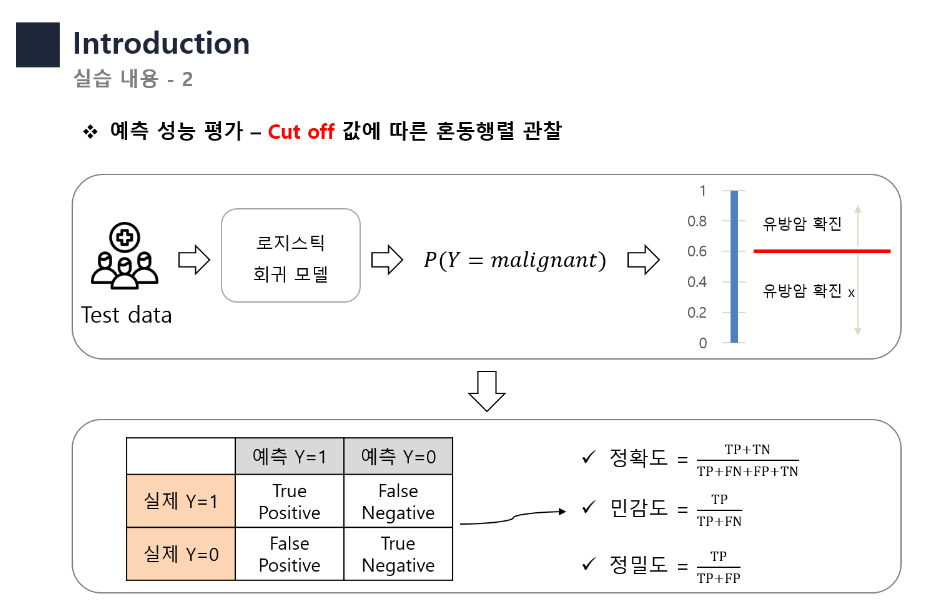

Cut off 값은 확률값을 보고 0이나 1으로 결정하는데 기준이되는 값.

Cut off 값보다 크면 1, 작으면 0

민감도 : 실제 유방암 환자 중에서 모델이 얼마나 환자를 잘 예측했는지 평가하는 지표.

정밀도 : 예측된 유방암 환자 중에서 실제 유방암 환자의 비율(평가 지표)

In [271]:
Cut_off = np.linspace(0.0000001,0.99,10) ## cut off 값 여러개 만들어두기 ### cut off 값을 0.0000001부터 0.99까지 변화시켜보며 보기.
for cutoff in Cut_off:
    y_pred = np.where(P_1.reshape(-1)>=cutoff,1,0) # 확률값이 cuf off보다 크면 1(유방암), 아니면 0(유방암x) # 각각의 cut off 값 기준으로 예측값 할당(평가지표는 패키지 함수 사용)
    acc = accuracy_score(y_true = y_test, y_pred =y_pred) ## 정확도
    recall = recall_score(y_true = y_test, y_pred =y_pred) ## 민감도
    precision = precision_score(y_true = y_test, y_pred =y_pred) ## 정밀도

    print(f"정확도:{acc:0.2f}",f"민감도:{recall:0.2f}",f"정밀도:{precision:0.2f}",f"cut off:{cutoff:0.2f}", sep='  |  ')

정확도:0.38  |  민감도:1.00  |  정밀도:0.38  |  cut off:0.00
정확도:0.94  |  민감도:0.97  |  정밀도:0.87  |  cut off:0.11
정확도:0.95  |  민감도:0.97  |  정밀도:0.91  |  cut off:0.22
정확도:0.96  |  민감도:0.95  |  정밀도:0.94  |  cut off:0.33
정확도:0.96  |  민감도:0.94  |  정밀도:0.95  |  cut off:0.44
정확도:0.97  |  민감도:0.94  |  정밀도:0.98  |  cut off:0.55
정확도:0.96  |  민감도:0.92  |  정밀도:0.98  |  cut off:0.66
정확도:0.96  |  민감도:0.91  |  정밀도:1.00  |  cut off:0.77
정확도:0.95  |  민감도:0.88  |  정밀도:1.00  |  cut off:0.88
정확도:0.92  |  민감도:0.78  |  정밀도:1.00  |  cut off:0.99


#### Roc curve 그리기

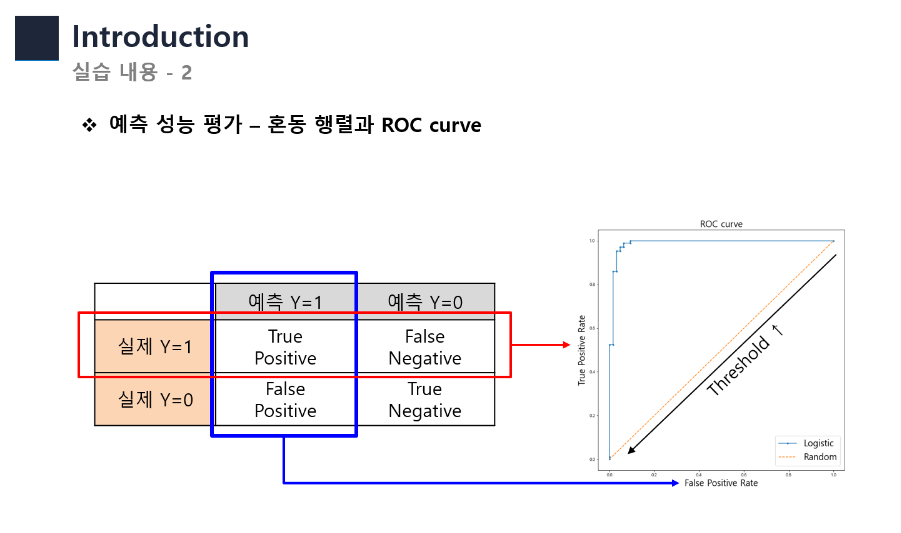

Roc curve 기준으로 하단에서부터 면적이 넓으면 좋은거(최대가 1)

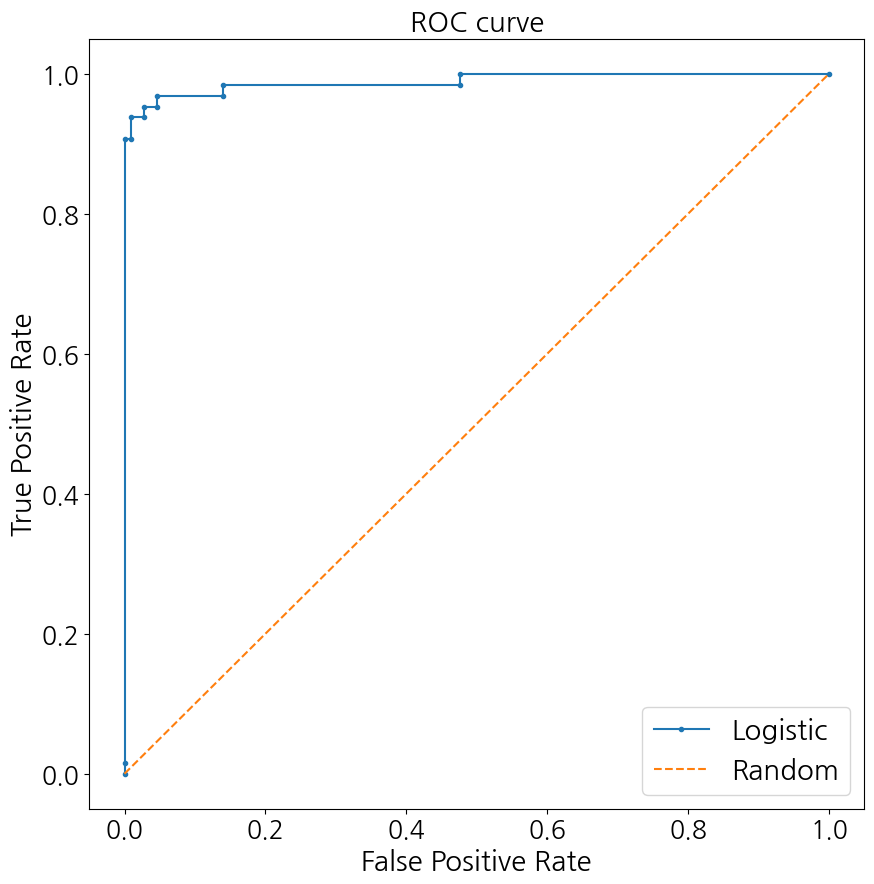

In [272]:
# X_test에 대한 P(Y=1) 예측 확률값 - 패키지 이용
probs = model.predict_proba(X_test)[:, 1] ## [:,1]은 두번째 컬럼을 indexing 한다는 뜻 # X_test에 대한 P(Y=1) 예측 확률값을 probs에 할당

# Roc curve X 축, Y축 추출
model_fpr, model_tpr, threshold1 = roc_curve(y_test, probs)  # y_test, probs을 roc_curve에 넣어주면 결과가 나옴 # model_fpr, model_tpr는 패키지가 자동으로 계산해줌.
random_fpr, random_tpr, threshold2 = roc_curve(y_test, [0 for i in range(X_test.__len__())])

# plot the roc curve for the model and random
plt.figure(figsize=(10,10))
plt.plot(model_fpr, model_tpr, marker='.', label='Logistic')
plt.plot(random_fpr, random_tpr, linestyle='--', label='Random')

# axis labels
plt.xlabel('False Positive Rate',size=20)
plt.ylabel('True Positive Rate',size=20)

# show the legend
plt.legend(fontsize=20)

# show the plot
plt.title("ROC curve",size=20)
plt.show()

점선인 random 값은 유방암이다/ 아니다를 random하게 찍은 값.(cut off값에 관계없이 (0,0)에서 (1,1)로 일직선으로 나타난다.)

예측한 ROC curve값이 random한 에측값보다 위에 나타나야 좋은 모델이다.

# 확률적 경사 하강법 (Stochastic Gradient Descent)
*   모델을 학습 시키기 위한 간단한 방법.
*   학습 파라미터에 대한 손실 함수의 기울기를 구해 기울기가 최소화 되는 방향으로 학습.

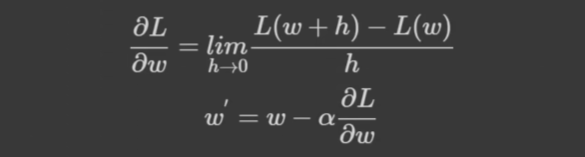

*   scikit-learn에서는 선형 SGD 회귀와 SGD 분류를 지원.

Regression, Classification 둘다에서 사용가능.

# SGD를 사용한 선형 회귀 분석

In [273]:
### 라이브러리 임포트

# SGDRegressor: 확률적 경사 하강법(SGD)을 이용한 회귀 모델입니다. 데이터가 매우 클 때 효율적입니다.
from sklearn.linear_model import SGDRegressor
# pd.read_csv: CSV 파일을 데이터프레임으로 읽어옵니다. 데이터를 표 형태로 다루기 위함입니다.
#from sklearn.datasets import load_boston
boston_df = pd.read_csv("boston.csv")  # "boston.csv" 파일을 읽어와 데이터프레임 형태로 저장합니다.
# train_test_split: 전체 데이터를 학습용과 검증용으로 나누어 모델의 일반화 성능을 측정하기 위해 사용합니다.
from sklearn.model_selection import train_test_split
# StandardScaler: 특성(Feature)들의 스케일을 평균 0, 표준편차 1로 맞춥니다. SGD는 스케일에 민감하므로 필수적입니다.
from sklearn.preprocessing import StandardScaler
# make_pipeline: 전처리(Scaler)와 모델(SGD)을 하나로 묶어 코드의 가독성을 높이고 데이터 누수를 방지합니다.
from sklearn.pipeline import make_pipeline

In [274]:
### 데이터 분리 및 결측치 처리

# Separate features (X) and target (y)
# X, y = load_boston(return_X_y=True)   # X와 y를 데이터셋에서 나눠줌
# 타겟 변수인 주택 가격('MEDV')을 제외한 나머지 변수들을 특징 데이터 X로 설정합니다
# drop: 'MEDV'(주택가격) 컬럼만 제외하고 X(특성 변수)를 만듭니다. 모델이 학습할 '문제지' 역할을 합니다.
X = boston_df.drop('MEDV', axis=1)
# 타겟 데이터 y: 우리가 예측해야 할 '정답지'인 주택 가격 데이터입니다.
y = boston_df['MEDV'] # 주택 가격('MEDV') 열을 타겟 데이터 y로 설정합니다.

# train_test_split: 데이터를 학습 데이터와 테스트 데이터로 분리합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [275]:
# make_pipeline(StandardScaler(), ...): 데이터를 먼저 표준화한 뒤 모델에 넣도록 설정합니다.
# loss='squared_error': 회귀에서 가장 일반적인 '평균 제곱 오차' 손실 함수를 사용하여 오차를 줄여나갑니다.
# model = make_pipeline(StandardScaler(), SGDRegressor(loss='squared_loss'))
model = make_pipeline(StandardScaler(), SGDRegressor(loss='squared_error'))

# fit: 학습 데이터(X_train)와 정답(y_train)을 넣어 모델이 데이터의 패턴을 학습하도록 합니다.
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdregressor', SGDRegressor())])

In [276]:
# score: 회귀 모델에서는 결정계수(R²)를 반환합니다. 1에 가까울수록 모델이 데이터를 잘 설명한다는 뜻입니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.7381370999318111
평가 데이터 점수: 0.7304054170433731


# 붓꽃 데이터에 대한 SGD 분류

In [277]:
# SGDClassifier: 확률적 경사 하강법을 활용한 분류기입니다. 대규모 데이터셋 분류에 적합합니다.
from sklearn.linear_model import SGDClassifier

# load_iris: 사이킷런에서 제공하는 붓꽃 예제 데이터를 불러오기 위한 함수입니다.
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [278]:
# load_iris(return_X_y=True): 데이터를 가져올 때 특성(X)과 타겟(y)을 분리된 튜플 형태로 바로 반환받습니다.
X, y = load_iris(return_X_y=True)

# 데이터를 학습용과 테스트용으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [279]:
# loss='log_loss': 로지스틱 회귀와 같은 확률 기반 분류를 수행하겠다는 설정입니다.
# 기본이 서포트 벡터 머신이다. 따라서 loss='log_loss'해야한다.
# 과거에는 'log'였으나 최신 버전에서는 'log_loss'로 명칭이 변경되었습니다.
# model = make_pipeline(StandardScaler(), SGDClassifier(loss='log'))
model = make_pipeline(StandardScaler(), SGDClassifier(loss='log_loss'))

# 준비된 붓꽃 데이터를 학습시킵니다.
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(loss='log_loss'))])

In [280]:
# score: 분류 모델에서는 '정확도(Accuracy)'를 반환합니다. 전체 중 몇 개를 맞췄는지를 나타냅니다.
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9464285714285714
평가 데이터 점수: 0.8947368421052632


# 유방암 데이터에 대한 SGD 분류

In [281]:
### 데이터 분할


# return_X_y=True: 원본 데이터셋의 복잡한 구조 대신, 특징 데이터(X)와 정답(y)만 딱 뽑아옵니다.
X, y = load_breast_cancer(return_X_y=True)

# 데이터를 섞고 분할합니다. 모델의 일반화 성능을 측정하기 위함입니다.
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [282]:
### 파이프라인(Pipeline) 설계 및 학습


# make_pipeline: 전처리(StandardScaler)와 모델(SGDClassifier)을 하나로 묶어주는 통로를 만듭니다.
# 이렇게 묶으면 나중에 새로운 데이터를 예측할 때도 똑같은 전처리를 자동으로 적용해줍니다.

# 1) StandardScaler(): 각 특성의 평균을 0, 표준편차를 1로 맞춥니다.
# 유방암 데이터처럼 각 변수의 수치 단위(Scale)가 크게 다를 때 모델이 헷갈리지 않게 도와줍니다.

# 2) SGDClassifier(loss='log_loss'): 확률적 경사하강법 분류기입니다.
# loss='log_loss': 로지스틱 회귀와 수학적으로 동일한 방식으로 작동하게 설정하는 옵션입니다.
# (구버전 scikit-learn에서는 'log'였으나 최신 버전에서는 'log_loss'를 사용합니다.)

# model = make_pipeline(StandardScaler(), SGDClassifier(loss='log'))
model = make_pipeline(StandardScaler(), SGDClassifier(loss='log_loss'))

# fit(): 파이프라인 안의 스케일러가 데이터를 학습(평균, 편차 계산)하고,
# 그 결과로 변환된 데이터를 SGD 알고리즘이 받아 가중치를 조절하며 훈련합니다.
model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sgdclassifier', SGDClassifier(loss='log_loss'))])

In [283]:
### 성능 점수 확인


# score(): 테스트 데이터를 넣었을 때 얼마나 잘 맞추는지 정확도를 계산합니다.
# 학습 데이터 점수: 훈련에 사용한 데이터로 얻은 점수 (모델이 얼마나 잘 수렴했는지 확인)
print("학습 데이터 점수: {}".format(model.score(X_train, y_train)))

# 평가 데이터 점수: 실제 서비스에 나갔을 때 예상되는 실력 (이 점수가 진짜 모델의 점수입니다.)
print("평가 데이터 점수: {}".format(model.score(X_test, y_test)))

학습 데이터 점수: 0.9741784037558685
평가 데이터 점수: 0.9790209790209791
